In [1]:

import pandas as pd
import geopandas as gpd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import shapely as wkt

import folium # For plots of geometry on interactive map
import matplotlib.colors as mcolors
import random

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"   # or: "notebook_connected"
from plotly.graph_objs import Font

import sys
from pathlib import Path

DATA_DIR = Path.cwd().parent / "data"
print("Data directory:", DATA_DIR.resolve())

benchmark_feeder = "012670401"  # Feeder in Alameda (Oakland) to Potentially use

Data directory: /Users/licin/OptimalChargerPlacement/data


# Importing Data

# Raw Data Import

### Grid Data

In [2]:
# Import Load data for all feeders

def get_loadDf_for_feeder(feeder_id):
    load_df_all_feeders = import_loadDf_all_feeders()
    feeder_loadDf = load_df_all_feeders[load_df_all_feeders['feeder_id'] == int(feeder_id)]
    renameColsDict = {'low_load_kw':'low_base_load_kw',
                      'high_load_kw': 'high_base_load_kw'}
    feeder_loadDf = feeder_loadDf.rename(columns=renameColsDict)

    return feeder_loadDf

# NEED TO MAKE FEEDER ID STRING
def import_loadDf_all_feeders(base_path=DATA_DIR):

    relative_folder_path = "cleanedGridData"
    filename = "feeder_load_profile_clean.csv"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    load_df_all_feeders = pd.read_csv(file_path)

    # load_df_all_feeders = pd.read_csv(file_path, dtype={'feeder_id': str})
    return load_df_all_feeders

test = get_loadDf_for_feeder(benchmark_feeder)
display(test)
load_df_all_feeders = import_loadDf_all_feeders()

,feeder_id,low_base_load_kw,high_base_load_kw,month,hour
69408,12670401,891.0,1068.0,1,0
69409,12670401,829.0,960.0,1,1
69410,12670401,763.0,900.0,1,2
69411,12670401,728.0,832.0,1,3
69412,12670401,702.0,787.0,1,4
...,...,...,...,...,...
69691,12670401,993.0,1234.0,12,19
69692,12670401,1006.0,1240.0,12,20
69693,12670401,1020.0,1258.0,12,21
69694,12670401,1006.0,1250.0,12,22


In [3]:
load_df_all_feeders

,feeder_id,low_load_kw,high_load_kw,month,hour
0,102041101,1057.0,1250.0,1,0
1,102041101,966.0,1117.0,1,1
2,102041101,951.0,1077.0,1,2
3,102041101,938.0,1057.0,1,3
4,102041101,964.0,1104.0,1,4
...,...,...,...,...,...
592411,83912110,4028.0,4944.0,12,19
592412,83912110,4077.0,4989.0,12,20
592413,83912110,4117.0,4962.0,12,21
592414,83912110,4074.0,4871.0,12,22


In [4]:
# Import metadata geodataframe for all feeders
# 1 row for each feeder
# 'feeder_id'	'division'	'substation'	'nom_volt_kV'	'Existing_DG'	'Queued_DG'	'shape_length'	'geometry'


def import_metaData_gdf_all_feeders(base_path=DATA_DIR):

    relative_folder_path = "cleanedGridData"
    filename = "feeder_meta_clean_gdf.gpkg"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    gdf_all_feeders = gpd.read_file(file_path)
    return gdf_all_feeders


feederMetadataGdf = import_metaData_gdf_all_feeders()
display(feederMetadataGdf.head())

,feeder_id,division,substation,nom_volt_kV,Existing_DG,Queued_DG,shape_length,geometry
0,163201102,Stockton,WEST POINT,12kV,2340,370,431704.873501,"MULTILINESTRING ((717038.22 4245680.843, 71703..."
1,083432111,San Jose,HICKS,21kV,4720,730,61473.923814,"MULTILINESTRING ((600661.102 4121410.616, 6006..."
2,022101109,Peninsula,SF H,12kV,1520,80,25925.744324,"MULTILINESTRING ((551452.358 4173482.555, 5513..."
3,043302103,Sonoma,MONROE,21kV,10210,1040,109445.067948,"MULTILINESTRING ((522459.857 4258793.177, 5224..."
4,162671103,Yosemite,WESTLEY,12kV,1870,5440,161530.404081,"MULTILINESTRING ((652837.489 4156520.205, 6527..."


In [5]:
# FEEDER/LINES ICA Data Import and Average functions

def get_feederAvgIcaDf(feeder_id):
  linesIcaDf = import_feederLineIcaDf_from_parquet(feeder_id)
  # Check that there is only one feeder_id in df
  unique_feeder_ids = linesIcaDf['feeder_id'].unique()
  if len(unique_feeder_ids) > 1:
    raise ValueError(f"More than one feeder_id found in df: {unique_feeder_ids}")

  feederIcaDf = avg_linesIca_for_feederIca(linesIcaDf)

  return feederIcaDf

def avg_linesIca_for_feederIca(linesIcaDf):
    ic_cols = ['IC10_Thermal_KW', 'IC10_Voltage_KW',
             'IC90_Thermal_KW', 'IC90_Voltage_KW']

    # --- Step 2: group by feeder, month, and hour and take the mean ---
    feederIcaDf = (
      linesIcaDf
      .groupby(['feeder_id', 'division', 'month', 'hour'])[ic_cols]
      .mean()
      .reset_index()
  )

    # Rename ic_cols so they are called avg
    ic_cols_new =   ['avg_IC10_Thermal_KW', 'avg_IC10_Voltage_KW',
                      'avg_IC90_Thermal_KW', 'avg_IC90_Voltage_KW']

    feederIcaDf = feederIcaDf.rename(columns = dict(zip(ic_cols, ic_cols_new)))

    # create new columns with min of the ic_cols_new
    feederIcaDf['minAvg_IC_KW'] = feederIcaDf[ic_cols_new].min(axis=1)

    # check result
    return feederIcaDf


# Import ICA data from parquet files
def import_feederLineIcaDf_from_parquet(feeder_id, base_path=DATA_DIR):
    """
  get_feeder_ICA_df_from_parquet

  :feeder_id: Feeder ID whose ICA data you want
  :folder_path: Path to the folder in Google Drive that holds the .parquet files
  :return: Pandas DataFrame
  """
    relative_folder_path = "cleanedGridData/ICA_Load_CLEAN_PARQUET_v4"
    filename = f"{feeder_id}.parquet"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_parquet(file_path)
    # rint(f"Loaded {filename} with {len(df)} rows and {len(df.columns)} columns.")
    return df

In [6]:
# TEST & DISPLYA ICA DATA
feederLinesIcaDf = import_feederLineIcaDf_from_parquet('012011108')
print("feederLinesIcaDf")
display(feederLinesIcaDf.head())

feederAvgIcaDf = get_feederAvgIcaDf(benchmark_feeder)
print('\n\nfeederAvgIcaDf')
display(feederAvgIcaDf.head(25))

feederLinesIcaDf


,line_section_id,month,hour,IC10_Thermal_KW,IC10_Voltage_KW,IC90_Thermal_KW,IC90_Voltage_KW,feeder_id,division
0,3030735,1,0,4800.0,2720.0,4830.0,2750.0,012011108,East Bay
1,3030735,1,1,4800.0,2720.0,4830.0,2750.0,012011108,East Bay
2,3030735,1,2,4790.0,2720.0,4820.0,2740.0,012011108,East Bay
3,3030735,1,3,4790.0,2720.0,4820.0,2740.0,012011108,East Bay
4,3030735,1,4,4790.0,2720.0,4820.0,2740.0,012011108,East Bay




feederAvgIcaDf


,feeder_id,division,month,hour,avg_IC10_Thermal_KW,avg_IC10_Voltage_KW,avg_IC90_Thermal_KW,avg_IC90_Voltage_KW,minAvg_IC_KW
0,012670401,East Bay,1,0,1172.758667,350.689667,923.655151,279.793091,279.793091
1,012670401,East Bay,1,1,1195.517212,356.551727,948.413818,243.655167,243.655167
2,012670401,East Bay,1,2,1194.827637,344.758606,947.586182,221.103455,221.103455
3,012670401,East Bay,1,3,1207.103394,345.931030,883.448303,202.620697,202.620697
4,012670401,East Bay,1,4,1207.034424,342.275848,882.551697,192.482758,192.482758
5,012670401,East Bay,1,5,1214.827637,345.241394,858.965515,180.551727,180.551727
6,012670401,East Bay,1,6,1263.793091,379.103455,931.310364,238.137924,238.137924
7,012670401,East Bay,1,7,1262.482788,387.241394,930.620667,258.896545,258.896545
8,012670401,East Bay,1,8,1264.000000,395.172424,932.275879,286.413788,286.413788
9,012670401,East Bay,1,9,1245.517212,386.620697,960.896545,290.344818,290.344818


### Census from Thibaud

In [7]:
# Import Census tract data
def import_census_block_gdf_for_charging(base_path=DATA_DIR):
    relative_folder_path = "Geography_Files"
    filename = "location_str_to_geoid_mapping.shp"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    gdf = gpd.read_file(file_path)
    return gdf

evCensusGdf = import_census_block_gdf_for_charging()
display(evCensusGdf.head())

,GEOID,GEOID_STR,INTPTLAT,INTPTLON,geometry
0,060014232002,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"POLYGON ((-122.29678 37.86529, -122.29581 37.8..."
1,060590423361,"1 (Tract 423.36, Orange, CA)",33.545621,-117.699173,"POLYGON ((-117.70528 33.54996, -117.70506 33.5..."
2,060014043002,"2 (Tract 4043, Alameda, CA)",37.844708,-122.241138,"POLYGON ((-122.24813 37.84139, -122.24749 37.8..."
3,060133851001,"1 (Tract 3851, Contra Costa, CA)",37.924964,-122.298942,"POLYGON ((-122.30682 37.93159, -122.30682 37.9..."
4,060952512002,"2 (Tract 2512, Solano, CA)",38.104862,-122.237457,"POLYGON ((-122.24357 38.10294, -122.24353 38.1..."


In [8]:
# Extract geodataframe for all block groups intersecting a given feeder
def blocks_intersecting_feeder_df(feeder_id, gdf_feeders, gdf_blocks):
    feeder_row = get_feeder_row(gdf_feeders, feeder_id)
    blocks_proj = reproject_blocks_to_feeder(gdf_blocks, gdf_feeders)
    feeder_geom = feeder_row.geometry.iloc[0]
    return get_intersecting_blocks(blocks_proj, feeder_geom)

# 1) tiny helper: get feeder row
def get_feeder_row(gdf_feeders, feeder_id, feeder_id_col="feeder_id"):
    feeder_row = gdf_feeders[gdf_feeders[feeder_id_col] == feeder_id]
    if feeder_row.empty:
        raise ValueError(f"No feeder found with ID {feeder_id}")
    return feeder_row

# 2) tiny helper: reproject blocks to feeder CRS
def reproject_blocks_to_feeder(gdf_blocks, gdf_feeders):
    if gdf_feeders.crs is None:
        raise ValueError("gdf_feeders has no CRS set")
    if gdf_blocks.crs is None:
        raise ValueError("gdf_blocks has no CRS set")
    return gdf_blocks.to_crs(gdf_feeders.crs)

# 3) tiny helper: get intersecting blocks (same CRS assumed)
def get_intersecting_blocks(blocks_same_crs, feeder_geom):
    mask = blocks_same_crs.intersects(feeder_geom)
    return blocks_same_crs[mask].copy()

intersectingBlocks = blocks_intersecting_feeder_df(benchmark_feeder, feederMetadataGdf, evCensusGdf)
display(intersectingBlocks)

,GEOID,GEOID_STR,INTPTLAT,INTPTLON,geometry
362,060014055001,"1 (Tract 4055, Alameda, CA)",37.795876,-122.240657,"POLYGON ((566616.929 4183371.888, 566633.276 4..."
1650,060014057002,"2 (Tract 4057, Alameda, CA)",37.796303,-122.227460,"POLYGON ((567821.221 4183333.789, 567859.021 4..."
2646,060014052001,"1 (Tract 4052, Alameda, CA)",37.804744,-122.239157,"POLYGON ((566550.281 4184133.408, 566550.819 4..."
6452,060014055004,"4 (Tract 4055, Alameda, CA)",37.800466,-122.245520,"POLYGON ((566116.057 4183926.411, 566126.069 4..."
8152,060014058001,"1 (Tract 4058, Alameda, CA)",37.792094,-122.230063,"POLYGON ((567514.28 4182915.284, 567551.289 41..."
8614,060014052003,"3 (Tract 4052, Alameda, CA)",37.806037,-122.244711,"POLYGON ((566090.442 4184429.954, 566096.834 4..."
10579,060014056003,"3 (Tract 4056, Alameda, CA)",37.801018,-122.240107,"POLYGON ((566656.715 4184003.894, 566685.767 4..."
11146,060014058004,"4 (Tract 4058, Alameda, CA)",37.796390,-122.236506,"POLYGON ((566942.706 4183372.201, 566991.827 4..."
11638,060014059012,"2 (Tract 4059.01, Alameda, CA)",37.789505,-122.234270,"POLYGON ((567109.487 4182765.398, 567114.478 4..."
13103,060014058003,"3 (Tract 4058, Alameda, CA)",37.794834,-122.234689,"POLYGON ((567092.228 4183337.912, 567120.649 4..."


#### Plots

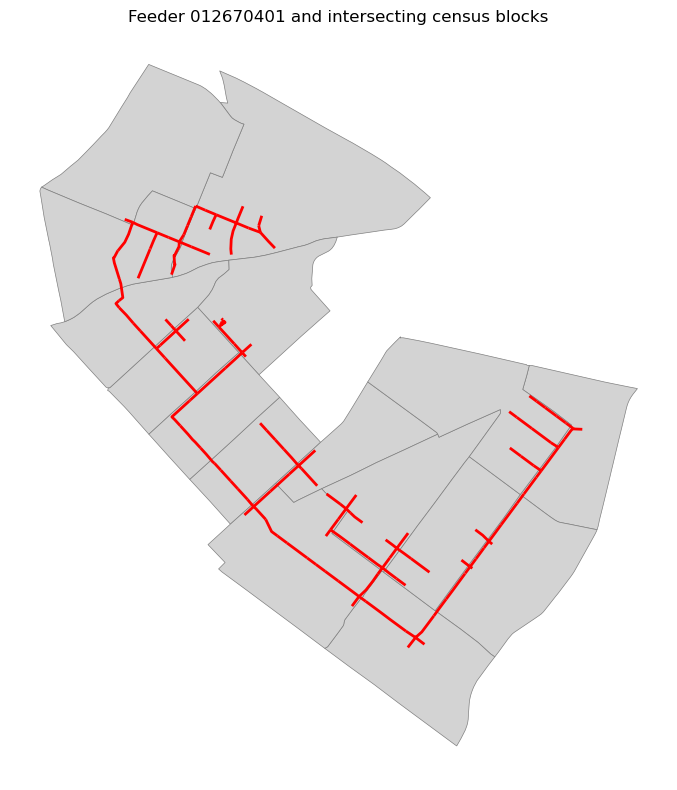

In [9]:
def plot_feeder_and_blocks(feeder_id, gdf_feeders, gdf_blocks):
    feeder_row = get_feeder_row(gdf_feeders, feeder_id)
    blocks_proj = reproject_blocks_to_feeder(gdf_blocks, gdf_feeders)
    feeder_geom = feeder_row.geometry.iloc[0]
    blocks_hit = get_intersecting_blocks(blocks_proj, feeder_geom)

    fig, ax = plt.subplots(figsize=(8, 8))

    if not blocks_hit.empty:
        blocks_hit.plot(ax=ax, facecolor="lightgray", edgecolor="gray", linewidth=0.5)

    feeder_row.plot(ax=ax, color="red", linewidth=2)

    ax.set_title(f"Feeder {feeder_id} and intersecting census blocks")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


plot_feeder_and_blocks(benchmark_feeder, feederMetadataGdf, intersectingBlocks)

In [10]:
# Create plot of overlapping blocks and feeder on interactive map
def folium_plot_feeder_and_blocks(
    feeder_id, gdf_feeders, gdf_blocks, unique_colors=True
):
    # put both in WGS84 for web map
    feeders_wgs = gdf_feeders.to_crs(epsg=4326)
    blocks_wgs = gdf_blocks.to_crs(epsg=4326)

    feeder_row = get_feeder_row(feeders_wgs, feeder_id)
    feeder_geom = feeder_row.geometry.iloc[0]

    blocks_hit = get_intersecting_blocks(blocks_wgs, feeder_geom)

    center = feeder_geom.representative_point().coords[0][::-1]
    m = folium.Map(location=center, zoom_start=12, tiles="OpenStreetMap")

    # style
    if unique_colors and not blocks_hit.empty:
        colors = random.sample(list(mcolors.CSS4_COLORS.keys()), len(blocks_hit))
        blocks_hit = blocks_hit.assign(_color=colors)
        style_fn = lambda feat: {
            "fillColor": feat["properties"]["_color"],
            "color": "black",
            "weight": 2,
            "fillOpacity": 0.55,
        }
    else:
        style_fn = lambda feat: {
            "fillColor": "#999999",
            "color": "black",
            "weight": 2,
            "fillOpacity": 0.45,
        }

    folium.GeoJson(
        blocks_hit,
        name="Intersecting blocks",
        style_function=style_fn,
    ).add_to(m)

    folium.GeoJson(
        feeder_row,
        name="Feeder",
        style_function=lambda x: {"color": "red", "weight": 5, "opacity": 0.9},
    ).add_to(m)

    folium.LayerControl().add_to(m)
    return m


folium_plot_feeder_and_blocks(benchmark_feeder, feederMetadataGdf, evCensusGdf)


### EV Projection Data

In [11]:
import ast
import re
def import_ev_projection_df(year, type="managed"):
    if year == "full_ev_adoption_alameda_load_curves.csv":
        rel_file_path = "sim_20251117_alameda_full_adoption/ev_load_curves.csv"
    elif year == "2035":
        rel_file_path = "sim_20251117_alameda_2035_adoption/ev_load_curves.csv"
    elif year == "2025":
        rel_file_path = "sim_20251117_alameda_2025_adoption/ev_load_curves.csv"

    print(year)
    file_path = os.path.join(DATA_DIR, 'EvChargingLoadCurves', rel_file_path)
    df = pd.read_csv(file_path)
    # Convert string "[...]" → Python list of floats
    if "load_curve" in df.columns:
        df["load_curve"] = df["load_curve"].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )
    return df


ev_projection_df = import_ev_projection_df("2035")
display(ev_projection_df.head())

2035


FileNotFoundError: [Errno 2] No such file or directory: '/Users/licin/OptimalChargerPlacement/data/EvChargingLoadCurves/sim_20251117_alameda_2035_adoption/ev_load_curves.csv'

### Aggregate Load Data for Blocks

In [ ]:
# Extract block number (including decimals) ---
def extract_block(geoid_str):
    if not isinstance(geoid_str, str):
        return None
    match = re.search(r"block\s+([\d.]+)", geoid_str)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            return None
    return None


# extract all rows of chargning data for a given census block
def filter_by_block(df, block_number):
    df = df.copy()

    # some geoids are just called out of region, remove those
    df = df[df["geoid"] != "Out of Region"]

    # df["block_num_int"] = df["geoid"].str.extract(r"block\s+(\d+)").astype(int)
    return df[df["block_float"] == float(block_number)]


def get_sum_charge_curve_lists(df_subset):
    """
    Sum multiple load_curve lists into one aggregate array.
    """
    if "load_curve" not in df_subset.columns:
        raise ValueError("DataFrame must contain a 'load_curve' column.")

    # Convert all to numpy arrays in case some are still lists
    curves = [np.array(curve, dtype=float) for curve in df_subset["load_curve"]]

    if len(curves) == 0:
        return []

    total_curve = np.sum(curves, axis=0)
    return total_curve.tolist()


def get_hourly_load_curve_from_15min(load_15min, method):
    """
    Convert a 15-minute load curve (length 96) to an hourly load curve (length 24).
    Either by average the 4 quarter-hours or take the max.

    Inputs
        loaad_15min : list or array-like 15-minute load values, expected length = 96.
        method : str, "avg" or "max"

    Returns: list of Hourly load curve (length 24).
    """
    arr = np.array(load_15min, dtype=float)

    if len(arr) % 4 != 0:
        raise ValueError(f"Expected length multiple of 4 (e.g. 96), got {len(arr)}")

    # reshape to (24, 4): 24 hours, 4 quarters each
    hourly_blocks = arr.reshape(-1, 4)

    if method == "avg":
        hourly = hourly_blocks.mean(axis=1)
    elif method == "max":
        hourly = hourly_blocks.max(axis=1)
    else:
        raise ValueError("method must be 'avg' or 'max'")

    return hourly.tolist()


# TESTING
# ev_projection_df = import_ev_projection_df()
# display(ev_projection_df)
# block_df = filter_by_block(ev_projection_df, '4059.02')

# display(block_df)
# type(block_df["load_curve"].iloc[1])

# sum = get_sum_load_curve_lists(block_df)
# print(sum)
# hrlyLoadCurve = get_hourly_load_curve_from_15min(sum, "avg")
# print(hrlyLoadCurve)

In [ ]:
# Function to get the total EV projected charging demand from all blocks intersecting a Feeder
def get_aggregate_evLoadDf_for_blocksDf(blocksGdf, evLoadDf):
    """
    blockssGdf is all the instersecting census blocks for a feeder
    """
    evLoadDf_matchingBlocks = pd.DataFrame()
    for index, row in blocksGdf.iterrows():
        block_geoID = row["GEOID_STR"]
        # Extract all rows of charging data that match the geoID of this block
        evLoadDf_forBlock = evLoadDf[evLoadDf["geoid"] == block_geoID]

        # display(evLoadDf_forBlock)
        # append block_df to projectionDf
        evLoadDf_matchingBlocks = pd.concat([evLoadDf_matchingBlocks, evLoadDf_forBlock], ignore_index=True)

    # 1) sum all 15-min load curves across those rows (length 96)
    sumChargeLoadList = get_sum_charge_curve_lists(
        evLoadDf_matchingBlocks
    )  # or your sum_load_curve_lists()

    # 2) convert to hourly avg and hourly peak (each length 24)
    avgHrlyLoadCurve = get_hourly_load_curve_from_15min(sumChargeLoadList, method="avg")
    peakHrlyLoadCurve = get_hourly_load_curve_from_15min(
        sumChargeLoadList, method="max"
    )

    # 3) build final 24-row dataframe
    out_df = pd.DataFrame(
        {
            "hour": list(range(24)),
            "hrlyAvgEVLoadKW": avgHrlyLoadCurve,
            "peakHrlyEVLoadKW": peakHrlyLoadCurve,
        }
    )

    return out_df


get_aggregate_evLoadDf_for_blocksDf(intersectingBlocks, ev_projection_df)


In [ ]:
# Function to get the total EV projected charging demand from all blocks intersecting a Feeder
def get_aggregate_evLoadDf_for_blocksDf(blocksGdf, evLoadDf):
    """
    blockssGdf is all the instersecting census blocks for a feeder
    """
    evLoadDf_matchingBlocks = pd.DataFrame()
    for index, row in blocksGdf.iterrows():
        block_geoID = row["GEOID_STR"]
        # Extract all rows of charging data that match the geoID of this block
        evLoadDf_forBlock = evLoadDf[evLoadDf["geoid"] == block_geoID]

        # display(evLoadDf_forBlock)
        # append block_df to projectionDf
        evLoadDf_matchingBlocks = pd.concat(
            [evLoadDf_matchingBlocks, evLoadDf_forBlock], ignore_index=True
        )

    # 1) sum all 15-min load curves across those rows (length 96)
    sumChargeLoadList = get_sum_charge_curve_lists(
        evLoadDf_matchingBlocks
    )  # or your sum_load_curve_lists()

    # 2) convert to hourly avg and hourly peak (each length 24)
    avgHrlyLoadCurve = get_hourly_load_curve_from_15min(sumChargeLoadList, method="avg")
    peakHrlyLoadCurve = get_hourly_load_curve_from_15min(
        sumChargeLoadList, method="max"
    )

    # 3) build final 24-row dataframe
    out_df = pd.DataFrame(
        {
            "hour": list(range(24)),
            "hrlyAvgEVLoadKW": avgHrlyLoadCurve,
            "peakHrlyEVLoadKW": peakHrlyLoadCurve,
        }
    )

    return out_df


# to get EV load growth for a given block subtract the estimated current demand from projected future charging demand
def get_projected_evLoadGrowthDf_for_blocksDf(
    blocksGdf, evLoadNowDf, evLoadProjectedDf
):
    nowDf = get_aggregate_evLoadDf_for_blocksDf(blocksGdf, evLoadNowDf)
    projectedDf = get_aggregate_evLoadDf_for_blocksDf(blocksGdf, evLoadProjectedDf)
    # growthDf = projectedDf - nowDf
    growthDf = projectedDf.set_index("hour").subtract(nowDf.set_index("hour"))
    growthDf = growthDf.reset_index()
    return growthDf


# display(get_aggregate_evLoadDf_for_blocksDf(intersectingBlocks, ev_projection_df))
evLoad2035Df = import_ev_projection_df("2035")
evLoad2025Df = import_ev_projection_df("2025")
evBlocksLoadGrowthDf = get_projected_evLoadGrowthDf_for_blocksDf(
    intersectingBlocks, evLoad2025Df, evLoad2035Df
)
display(evBlocksLoadGrowthDf)

## Plot Functions

In [ ]:
def plot_add_grid_legend_tight():
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

In [ ]:
# PLOT AVG ICA DATA FOR A FEEDER

def plot_feeder_ica_concatenated(feeder_id):
    """
    Plot 4 ICA columns over a concatenated timeline:
    each month contributes 24 hours on the x-axis.
    Result: 4 lines total.
    """
    feederIcaDf = get_feederAvgIcaDf(feeder_id)
    ic_cols =   ['avg_IC10_Thermal_KW', 'avg_IC10_Voltage_KW',
                      'avg_IC90_Thermal_KW', 'avg_IC90_Voltage_KW']

    # filter to this feeder
    df_f = feederIcaDf[feederIcaDf['feeder_id'] == feeder_id].copy()
    if df_f.empty:
        print(f"No data for feeder {feeder_id}")
        return

    # make sure months are in order
    months = sorted(df_f['month'].unique())

    # we will build arrays in month order
    all_hours = []
    data_by_col = {col: [] for col in ic_cols}

    for mi, m in enumerate(months):
        df_m = df_f[df_f['month'] == m].sort_values('hour')

        # x positions for this month: shift by 24 * month_index
        base = mi * 24
        x_this_month = base + df_m['hour'].to_numpy()
        all_hours.append(x_this_month)

        for col in ic_cols:
            data_by_col[col].append(df_m[col].to_numpy())

    # concatenate
    x = np.concatenate(all_hours)
    for col in ic_cols:
        data_by_col[col] = np.concatenate(data_by_col[col])

    # plot
    plt.figure(figsize=(10, 5))
    for col in ic_cols:
        plt.plot(x, data_by_col[col], marker='.', label=col)

    # x-ticks at the start of each month block
    month_xticks = [i * 24 for i in range(len(months))]
    month_xticklabels = [f"Month {m}" for m in months]
    plt.xticks(month_xticks, month_xticklabels, rotation=0)

    plt.title(f"Feeder {feeder_id} – ICA over months (24h per month)")
    plt.xlabel("Month (each = 24 hours)")
    plt.ylabel("ICA (kW)")
    plt.xlim(0, x[-1])     # set xlim to start at 0
    plot_add_grid_legend_tight()
    plt.show()

plot_feeder_ica_concatenated(benchmark_feeder)

## Analysis

In [ ]:
# Run functions that import raw data
evCensusGdf = import_census_block_gdf_for_charging()
evLoad2035Df = import_ev_projection_df("2035")
evLoad2025Df = import_ev_projection_df("2025")
feedersMetadataGdf = import_metaData_gdf_all_feeders()

list_some_alameda_feeders = ["013840405", "012670401", "012091102", "012501108"]

### Functions

In [ ]:
def get_merged_hrly_power_df(feederBaseLoadDf, feederIcaDf, evLoadDf):
    # 1) check feeder_id uniqueness in both DFs
    base_ids = feederBaseLoadDf["feeder_id"].unique()
    ica_ids = feederIcaDf["feeder_id"].unique()

    if len(base_ids) != 1:
        raise ValueError(
            f"feederBaseLoadDf has {len(base_ids)} feeder_ids, expected 1: {base_ids}"
        )
    if len(ica_ids) != 1:
        raise ValueError(
            f"feederIcaDf has {len(ica_ids)} feeder_ids, expected 1: {ica_ids}"
        )

    if float(base_ids[0]) != float(ica_ids[0]):
        raise ValueError(f"feeder_id mismatch: base={base_ids[0]}, ica={ica_ids[0]}")

    # 2) merge base + ICA, keep only one feeder_id
    merged = pd.merge(
        feederIcaDf,
        feederBaseLoadDf,
        on=["month", "hour"],
        how="inner",
        suffixes=("", "_ica"),
    )

    # after merge ther is 'feeder_id' (from base) and possibly 'feeder_id_ica'
    if "feeder_id_ica" in merged.columns:
        merged = merged.drop(columns=["feeder_id_ica"])

    # 3) repeat EV hourly data for every month present in merged
    # evLoadDf is assumed to have columns: ['hour', ...]
    months = merged["month"].unique()
    months_df = pd.DataFrame({"month": months})

    # cartesian product months x evLoadDf
    evLoad_expanded = months_df.merge(evLoadDf, how="cross")

    # 4) merge EV hourly data in
    # now evLoad_expanded has ['month', 'hour', 'hrlyAvgEVLoadKW', 'peakHrlyEVLoadKW', ...]
    merged_all = pd.merge(
        merged,
        evLoad_expanded,
        on=["month", "hour"],
        how="left",
    )

    return merged_all


def get_results_df(mergedDf):
    keepCols = [
        "feeder_id",
        "division",
        "month",
        "hour",
        "minAvg_IC_KW",
        "high_base_load_kw",
        "hrlyAvgEVLoadKW",
    ]
    resultsDf = mergedDf[keepCols].copy()
    resultsDf["stress"] = (
        resultsDf["high_base_load_kw"] + resultsDf["hrlyAvgEVLoadKW"]
    ) / (resultsDf["high_base_load_kw"] + resultsDf["minAvg_IC_KW"])
    resultsDf["overload_kw"] = resultsDf["hrlyAvgEVLoadKW"] - resultsDf["minAvg_IC_KW"]
    return resultsDf

In [ ]:
# TESTING

avgFeederIcaDf = get_feederAvgIcaDf(benchmark_feeder)

intersectingCensusBlocksDf = blocks_intersecting_feeder_df(benchmark_feeder, feedersMetadataGdf, evCensusGdf)
aggEvBlocksLoadGrowthDf = get_projected_evLoadGrowthDf_for_blocksDf(intersectingBlocks, evLoad2025Df, evLoad2035Df)

# display(aggEvBlocksLoadGrowthDf.head())

feederBaseLoadDf = get_loadDf_for_feeder(benchmark_feeder)

test_unmngdHrlyPowerDf = get_merged_hrly_power_df(feederBaseLoadDf, avgFeederIcaDf, aggEvBlocksLoadGrowthDf)
test_unmngdHrlyResultsDf = get_results_df(test_unmngdHrlyPowerDf)
print('test_unmngdHrlyPowerDf')
display(test_unmngdHrlyPowerDf.head())
print('test_unmngdHrlyResultsDf')
display(test_unmngdHrlyResultsDf.head())

# Find and print the line with max overload
max_overload_row = test_unmngdHrlyResultsDf.loc[test_unmngdHrlyResultsDf['overload_kw'].idxmax()]
print("Maximum Overload:")
display(max_overload_row['overload_kw'])

# Find and print the line with max stress
max_stress_row = test_unmngdHrlyResultsDf.loc[test_unmngdHrlyResultsDf['stress'].idxmax()]
print("\nMaximum Stress:")
display(max_stress_row['stress'])

### Plot Results

In [ ]:
# ---- Shared style constants ----
MAIN_COLOR = "#010133"  # axis labels, ticks, border, title
LINE_COLORS = [
    "#004AAE",
    "#FDB515",
    "#9FD1FF",
    "#002676",
]  # for curves


def apply_pretty_plot_style(ax, title=None, xlabel=None, ylabel=None):
    """
    Apply shared styling: colors, ticks, border, etc.
    """
    # Title and axis labels
    if title is not None:
        ax.set_title(title, color=MAIN_COLOR, fontsize=18, pad=8)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=MAIN_COLOR, fontsize=15)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=MAIN_COLOR, fontsize=15)

    # Ticks
    ax.tick_params(axis="x", colors=MAIN_COLOR, labelsize=12)
    ax.tick_params(axis="y", colors=MAIN_COLOR, labelsize=12)

    # Border/spines
    for spine in ax.spines.values():
        spine.set_color(MAIN_COLOR)

    # Make grid light and clean
    ax.grid(linestyle="--", alpha=0.3)


def plot_add_grid_legend_tight():
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

In [ ]:
def plot_feeder_results(resultsDf, feeder_id_col="feeder_id"):
    """
    Plot power (kW) and stress for a single feeder across all months and hours.
    resultsDf must include columns:
        ['month', 'hour', 'stress', 'minAvg_IC_KW', 'high_base_load_kw',
         'hrlyAvgEVLoadKW', 'overload_kw']
    """

    # --- Ensure sorted by month/hour ---
    resultsDf = resultsDf.sort_values(["month", "hour"]).reset_index(drop=True)

    # --- Build x-axis (1–288 points for 12×24) ---
    x = range(len(resultsDf))
    xticks = [i * 24 for i in range(resultsDf["month"].nunique())]
    xlabels = [f"Month {m}" for m in sorted(resultsDf["month"].unique())]

    # --- Create figure with twin y-axes ---
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- Plot power data (left y-axis, in kW) ---
    power_cols = ["minAvg_IC_KW", "high_base_load_kw", "hrlyAvgEVLoadKW", "overload_kw"]
    colors = ["tab:green", "tab:blue", "tab:orange", "tab:red"]
    for col, color in zip(power_cols, colors):
        if col in resultsDf.columns:
            ax1.plot(x, resultsDf[col], label=col, color=color, linewidth=2)
            # ax1.scatter(x, resultsDf[col], color=color, s=10)

    ax1.set_xlabel("Month (each = 24 hours)")
    ax1.set_ylabel("Power (kW)", color="black")
    ax1.tick_params(axis="y", labelcolor="black")
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xlabels, rotation=0)
    ax1.grid(True, alpha=0.3)

    # --- Secondary y-axis for stress ---
    ax2 = ax1.twinx()
    ax2.plot(
        x,
        resultsDf["stress"],
        label="stress",
        color="tab:purple",
        linewidth=3,
        linestyle="--",
    )
    ax2.set_ylabel("Stress", color="tab:purple")
    ax2.tick_params(axis="y", labelcolor="tab:purple")

    # --- Combine legends from both axes ---
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=9)

    # --- Title ---
    feeder_id = (
        resultsDf[feeder_id_col].iloc[0]
        if feeder_id_col in resultsDf.columns
        else "Feeder"
    )
    ax1.set_title(
        f"Feeder {feeder_id} – Power and Stress over Months (24h per month)",
        fontsize=13,
    )

    plt.tight_layout()
    plt.show()


plot_feeder_results(test_unmngdHrlyResultsDf)

In [ ]:
# PRETTY PLOT FOR PRESENTATIONS


def plot_feeder_results_pretty(
    resultsDf,
    power_cols=["minAvg_IC_KW", "hrlyAvgEVLoadKW"],
    legend_labels=["Minimum Additional Hosting Capacity", "EV Load Growth by 2035"],
    title=None,
    feeder_id_col="feeder_id",
):
    """
    Simpler, presentation-style plot:
    - Plots selected power columns (default: minAvg_IC_KW, hrlyAvgEVLoadKW)
    - Uses nicer colors and legend labels
    """

    # --- Ensure sorted by month/hour ---
    resultsDf = resultsDf.sort_values(["month", "hour"]).reset_index(drop=True)

    # --- Build x-axis (1–288 points for 12×24) ---
    x = range(len(resultsDf))
    months = sorted(resultsDf["month"].unique())
    xticks = [resultsDf[resultsDf["month"] == m].index[0] for m in months]
    month_xticklabels = [calendar.month_abbr[m] for m in months]  # <-- NEW

    # xlabels = [f"Month {m}" for m in months]

    # --- Create figure ---
    fig, ax = plt.subplots(figsize=(10, 5))

    # --- Plot requested power columns ---
    for i, col in enumerate(power_cols):
        if col not in resultsDf.columns:
            continue  # skip if missing

        label = legend_labels[i] if i < len(legend_labels) else col
        color = LINE_COLORS[i % len(LINE_COLORS)]

        ax.plot(x, resultsDf[col], label=label, color=color, linewidth=2.5)

    # --- X-axis formatting ---

    ax.set_xticks(xticks)
    ax.set_xticklabels(month_xticklabels, rotation=0)
    ax.set_xlim(xmin=0)

    # --- Apply shared style ---
    feeder_id = (
        resultsDf[feeder_id_col].iloc[0]
        if feeder_id_col in resultsDf.columns
        else "Feeder"
    )
    if title is None:
        title = f"Feeder {feeder_id} – Hosting Capacity vs EV Load Growth By 2035"
    apply_pretty_plot_style(
        ax,
        title=title,
        xlabel="Month (24 hours for each month)",
        ylabel="Power (kW)",
    )

    # --- Legend styling ---
    legend = ax.legend(frameon=False, ncol=2, loc="upper left", fontsize=13)
    for text in legend.get_texts():
        text.set_color(MAIN_COLOR)

    plt.tight_layout()
    plt.show()


plot_feeder_results_pretty(test_unmngdHrlyResultsDf)

In [ ]:
def interactive_results_plot(resultsDf):
    fig = px.line(
        resultsDf,
        x=resultsDf.index,
        y=["minAvg_IC_KW", "high_base_load_kw", "hrlyAvgEVLoadKW", "overload_kw"],
        hover_data=["month", "hour"],
        labels={"value": "kW", "variable": "Series"},
        title="Feeder – Power and Stress over Months",
    )

    # Add stress on secondary axis
    fig.add_scatter(
        x=resultsDf.index,
        y=resultsDf["stress"],
        mode="lines",
        name="stress",
        yaxis="y2",
    )

    # Configure axes
    fig.update_layout(
        yaxis=dict(title="Power (kW)"),
        yaxis2=dict(title="Stress", overlaying="y", side="right"),
        legend=dict(x=0.01, y=0.99),
    )

    fig.show()


interactive_results_plot(test_unmngdHrlyResultsDf)

### Run

#### New

In [ ]:
# find all tracts intersecting the specified feeder
# Get the EV projection data for those tracts and aggregate relavent data
# Transform ev projection data into form that matches ICA and load data, hour, month


def run_unmanaged_scenario(
    feeder_id,
    evCensusGdf=evCensusGdf,
    evLoadNowDf=evLoad2025Df,
    evLoadFutureDf=evLoad2035Df,
    feedersMetadataGdf=feedersMetadataGdf,
):
    benchmark_feeder = feeder_id
    feederBaseLoadDf = get_loadDf_for_feeder(benchmark_feeder)
    avgFeederIcaDf = get_feederAvgIcaDf(benchmark_feeder)
    intersectingCensusBlocksDf = blocks_intersecting_feeder_df(
        benchmark_feeder, feedersMetadataGdf, evCensusGdf
    )
    # aggEvLoadDf = get_aggregate_evLoadDf_for_blocksDf(intersectingBlocksCensusDf, projectedEvLoadDf)
    aggEvBlocksLoadGrowthDf = get_projected_evLoadGrowthDf_for_blocksDf(
        intersectingCensusBlocksDf, evLoad2025Df, evLoad2035Df
    )
    hrlyPowerDf = get_merged_hrly_power_df(
        feederBaseLoadDf, avgFeederIcaDf, aggEvBlocksLoadGrowthDf
    )

    hrlyResultsDf = get_results_df(hrlyPowerDf)
    return hrlyPowerDf, hrlyResultsDf


def plot_and_print_unmanaged_results(feeder_id, df_hrlyResults):
    print(f"Feeder {feeder_id} Unmanaged Results:")
    # display(df_hrlyResults)

    # Find and print the line with max overload
    max_overload_row = df_hrlyResults.loc[df_hrlyResults["overload_kw"].idxmax()]
    print("Maximum Overload:")
    display(max_overload_row["overload_kw"])

    # Find and print the line with max stress
    max_stress_row = df_hrlyResults.loc[df_hrlyResults["stress"].idxmax()]
    print("\nMaximum Stress:")
    display(max_stress_row["stress"])

    # plot_feeder_results(df_hrlyResults)
    plot_feeder_results_pretty(df_hrlyResults)
    # interactive_results_plot(df_hrlyResults)

In [ ]:
for feeder in list_some_alameda_feeders:
    hrlyPowerDf, hrlyResultsDf = run_unmanaged_scenario(feeder)
    plot_and_print_unmanaged_results(feeder, hrlyResultsDf)

#### Old

# Plot Feeders in Census Block

In [ ]:
# find feeders that intersect a single census block, 
def feeders_intersecting_block_df(block_id, gdf_blocks, gdf_feeders, block_id_col="GEOID"):
    block_row = get_block_row(gdf_blocks, block_id, block_id_col)
    feeders_proj = reproject_feeders_to_block(gdf_feeders, gdf_blocks)
    block_geom = block_row.geometry.iloc[0]
    return get_intersecting_feeders(feeders_proj, block_geom)

# 1) tiny helper: get block row
def get_block_row(gdf_blocks, block_id, block_id_col="GEOID"):
    block_row = gdf_blocks[gdf_blocks[block_id_col] == block_id]
    if block_row.empty:
        raise ValueError(f"No block found with ID {block_id}")
    return block_row

# 2) tiny helper: reproject feeders to block CRS
def reproject_feeders_to_block(gdf_feeders, gdf_blocks):
    if gdf_blocks.crs is None:
        raise ValueError("gdf_blocks has no CRS set")
    if gdf_feeders.crs is None:
        raise ValueError("gdf_feeders has no CRS set")
    return gdf_feeders.to_crs(gdf_blocks.crs)

# 3) tiny helper: get intersecting feeders
def get_intersecting_feeders(feeders_same_crs, block_geom):
    mask = feeders_same_crs.intersects(block_geom)
    return feeders_same_crs[mask].copy()

In [ ]:
block_id="060014057002"
print("block id:", block_id)

intersecting_feeders = feeders_intersecting_block_df(
    block_id,
    gdf_blocks=evCensusGdf,
    gdf_feeders=feederMetadataGdf
)


#tract_id= "060014052001",
    #tract_id="060014057002",
    #tract_id = "060014055001",

intersecting_feeders

In [ ]:
import matplotlib.cm as cm

# tract_row: GeoDataFrame with the single census block
# intersecting_feeders: GeoDataFrame with only the intersecting feeders
block_row = evCensusGdf[evCensusGdf['GEOID']==block_id]

num_feed = len(intersecting_feeders)
colors = cm.viridis(np.linspace(0, 1, num_feed))  # unique color for each feeder

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the census block
block_row.plot(ax=ax, color="orange", edgecolor="black")

# Plot each feeder row separately in a different color
for i in range(num_feed):
    feeder_row = intersecting_feeders.iloc[i:i+1]  # single-row GeoDataFrame
    feeder_row.plot(
        ax=ax,
        color=colors[i],
        linewidth=2,
        label=f"Feeder {feeder_row['feeder_id'].values[0]}"  # use your actual feeder ID column
    )

ax.set_title("Census Block with Intersecting Feeders")
plt.axis("off")
plt.legend()
plt.show()

## Feeder Block Matrix Overlapping

In [ ]:
#find lengths of intersections for census blocks
from shapely.geometry import MultiLineString, LineString

# reproject to meters (UTM zone 10N for Oakland area)
block_row_proj = block_row.to_crs(epsg=32610)
intersecting_feeders_proj = intersecting_feeders.to_crs(epsg=32610)

intersecting_feeders_proj

block_geom = block_row_proj.loc[block_row_proj['GEOID'] == block_id, 'geometry'].values[0]

lengths_inside_block = []


for i, feeder in intersecting_feeders_proj.iterrows():
    feeder_geom = feeder.geometry
    clipped_geom = feeder_geom.intersection(block_geom)

    if clipped_geom.is_empty:
        length = 0
        print("is empty")
    elif isinstance(clipped_geom, LineString):
        length = clipped_geom.length
    elif isinstance(clipped_geom, MultiLineString):
        # Use .geoms to iterate over LineStrings
        length = sum(line.length for line in clipped_geom.geoms)
    else:
        length = 0  # fallback for unexpected geometry types
        print("unexpected")

    lengths_inside_block.append(length)

intersecting_feeders_proj['length_in_block_m'] = lengths_inside_block
intersecting_feeders_proj

In [ ]:
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString

# CRS for Bay Area can be set to 32610 (when working in meters)
# CRS for some parts of California need to be adjusted
blocks_proj_m = evCensusGdf.to_crs(epsg=32610)
feeders_proj_m = feederMetadataGdf.to_crs(epsg=32610)

intersections = gpd.overlay(
    feeders_proj_m,
    blocks_proj_m,
    how="intersection"
)
display(intersections.head())

In [ ]:
def get_length(geom):
    if geom.is_empty:
        return 0
    elif isinstance(geom, LineString):
        return geom.length
    elif isinstance(geom, MultiLineString):
        return sum(line.length for line in geom.geoms)
    else:
        # GeometryCollection: sum only LineStrings
        return sum(g.length for g in geom.geoms if isinstance(g, LineString))

In [ ]:
intersections["length_in_block_m"] = intersections.geometry.apply(get_length)

# total length per block
block_totals = intersections.groupby("GEOID")["length_in_block_m"].sum().rename("total_length_in_block")
intersections = intersections.merge(block_totals, on="GEOID")

# fraction of each feeder in its block
intersections["fraction"] = intersections["length_in_block_m"] / intersections["total_length_in_block"]

intersections[intersections["feeder_id"] == benchmark_feeder].head()

In [ ]:
feeder_block_matrix = intersections.pivot_table(
    index="feeder_id",   # replace with your feeder ID column
    columns="GEOID",
    values="fraction",
    fill_value=0
)

display(feeder_block_matrix)

In [ ]:
feeder_block_matrix["060014001001"].sum()

In [ ]:
# CHECKING THE INTERSECTION WORKED CORRECTLY
# Add row to feeder_block_matrix which is the sum of each column
court_row = pd.DataFrame(feeder_block_matrix.sum(axis=0)).T
court_row.index = ["Court_Sum"]

# Find all unique values in court_row
# If it works correctly, there should only be 0s and 1s
# unique_values = court_row.loc["Court_Sum"].unique()
# print("Unique values in Court_Sum row:", unique_values)
# print(pd.unique(court_row.loc["Court_Sum"]))

vals = feeder_block_matrix.sum(axis=0).unique()
np.set_printoptions(precision=16)
print(vals)

In [ ]:
# print date


In [ ]:
print(feeder_block_matrix['060014057002'][feeder_block_matrix['060014057002'] != 0])
print("\n")
print(
    feeder_block_matrix.loc[benchmark_feeder][
        feeder_block_matrix.loc[benchmark_feeder] != 0
    ]
)

In [ ]:
feeder_block_matrix.to_parquet('../data/network_analysis/feeder_block_matrix.parquet')

In [ ]:
hrlyPowerDf

In [ ]:
hrlyResultsDf

In [ ]:
load_df_all_feeders[['high_load_kw']].boxplot()

In [ ]:
def get_max_load(df, col = 'high_load_kw', remove_outliers = True):
    df = df[[col, 'feeder_id']]
    if remove_outliers:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df_cleaned = df[~((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR)))]
    else:
        df_cleaned = df
    best_rows = df_cleaned.loc[df_cleaned.groupby('feeder_id')[col].idxmax()].reset_index(drop=True)
    # print(best_rows.dtypes)
    return best_rows


In [ ]:
from tqdm import tqdm
dir = os.listdir(DATA_DIR / 'cleanedGridData' / 'ICA_Load_CLEAN_PARQUET_v4')
feeder_capacities = []
for f in tqdm(dir):
    if f.split('.')[-1] != 'parquet': 
        continue
    feeder_df = import_feederLineIcaDf_from_parquet(f.split('.')[0])
    feeder_capacities.append(get_max_load(feeder_df, 'IC10_Voltage_KW'))

In [ ]:
### Creating an example of what we need the capacities to look like. Not sure if what we need is already done. 
# here just taking the max capacity and max load and subtracting, but could join on month/hour and take lowest capacities

In [ ]:
feeder_capacities[0].dtypes
example_capacities_df = pd.concat(feeder_capacities)
example_capacities_df.feeder_id
# example df with existing loads
example_loads_df = get_max_load(load_df_all_feeders)
display(example_loads_df.head())
print(example_loads_df.feeder_id)

In [ ]:
example_optimization_input_df = example_loads_df[['feeder_id','high_load_kw']].merge(example_capacities_df[['feeder_id','IC10_Voltage_KW']], on = 'feeder_id')
example_optimization_input_df['available_capacity'] = example_optimization_input_df['IC10_Voltage_KW'] - example_optimization_input_df['high_load_kw']
example_optimization_input_df = example_optimization_input_df[['feeder_id','available_capacity']].sort_values('available_capacity')
display(example_optimization_input_df)

In [ ]:
# Not sure this data is good since there are already some pretty negative values for some feeders, but is ok for developing code 
example_optimization_input_df.to_parquet('../data/network_analysis/example_grid_constraint_df.parquet')

## Stress Plot for California by Census Block